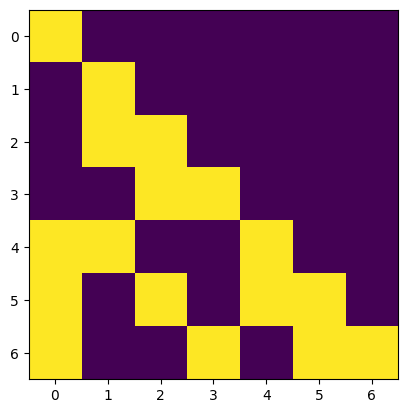

In [20]:
from probjax.utils.graph import min_faithfull_mask

import jax.numpy as jnp
import matplotlib.pyplot as plt


mask_base = jnp.eye(7, dtype=bool)
mask_base = mask_base.at[4:, 0].set(True)
mask_base = mask_base.at[6,5].set(True)
mask_base = mask_base.at[5,4].set(True)
mask_base = mask_base.at[2,1].set(True)
mask_base = mask_base.at[3,2].set(True)
mask_base = mask_base.at[4,1].set(True)
mask_base = mask_base.at[5,2].set(True)
mask_base = mask_base.at[6,3].set(True)

plt.imshow(mask_base)

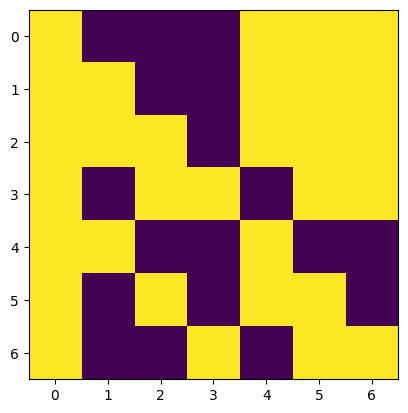

In [21]:
plt.imshow(min_faithfull_mask(mask_base, jnp.array([False]*4 + [True]*3)))

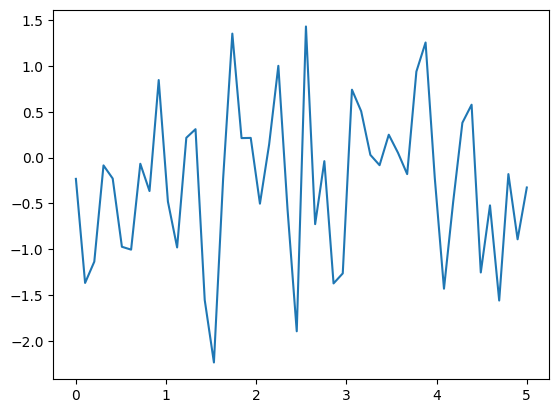

In [51]:
import seaborn as sns
import jax

def sample_GP(N, X, sigma, l):
    K = jax.vmap(lambda x: jax.vmap(lambda y: jnp.exp(-0.5/l**2 * (x-y)**2))(X))(X)
    L = jnp.linalg.cholesky(K + sigma**2 * jnp.eye(N))
    return jax.random.multivariate_normal(jax.random.PRNGKey(0), jnp.zeros(N), L)


N = 50
X = jnp.linspace(0, 5, N)
sigma = 1.
l = 5.
y = sample_GP(N, X, sigma, l)

plt.plot(X, y)